# EDA (Exploratory Data Analysis) i vizualizacija audio signala (waveform i Mel spektrogram)

- Ova skripta služi za brzu vizualizaciju audio uzoraka iz RAVDESS dataset-a i čuvanje slika za svaku kombinaciju pol + emocija.

- Prolazi kroz sve .wav fajlove u dataset-u.

- Parsira ime fajla da odredi:

    - Emociju

    - Pol (na osnovu ID glumca)

- Za svaku kombinaciju pol + emocija, pravi se samo jedan prikaz da se ne dupliraju slike.


---

## Statistička analiza skupa podataka

Pre kvalitativnog pregleda primera (waveform/Mel spektrogram ispod), sledi kvantitativna analiza: raspodela klasa, pola, glumaca i trajanja zapisa, i na kraju vizualizacija prostora karakteristika.

### 1. Raspodela emocija

RAVDESS nije potpuno balansiran skup: emocija *neutral* postoji samo u jednom intenzitetu (dok ostalih 7 emocija imaju po dva intenziteta), pa ima upola manje zapisa. Ovo je bitno imati u vidu pri tumačenju rezultata klasifikacije — model ima manje primera za učenje kategorije *neutral*.

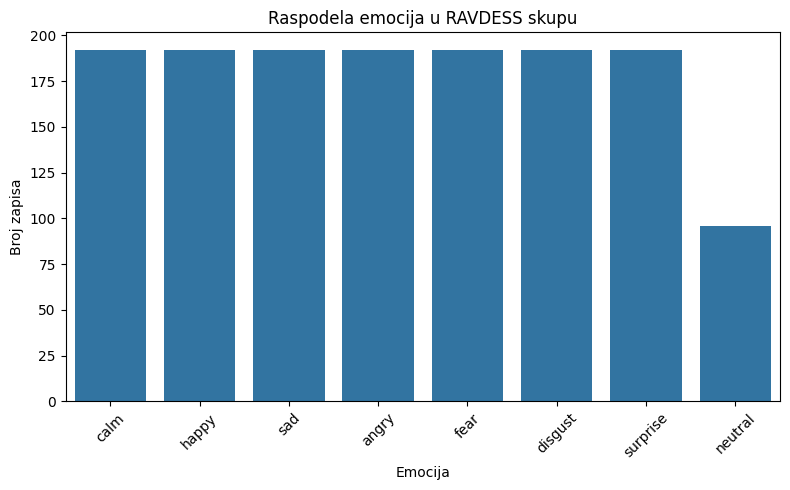

emotion
calm        192
happy       192
sad         192
angry       192
fear        192
disgust     192
surprise    192
neutral      96
Name: count, dtype: int64


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("visualization/eda_photos", exist_ok=True)

df_labels = pd.read_csv("data/processed_data/audio_labels.csv")

# audio_labels.csv cuva putanje relativne prema folderu iz kog je pokrenut
# extract_labels.py (obicno "features/"). Ova sveska se pokrece iz korena
# projekta, pa putanje normalizujemo na "data/raw/<Actor_XX>/<fajl>.wav"
# nezavisno od toga odakle je CSV nastao.
df_labels["path"] = df_labels["path"].apply(
    lambda p: os.path.join("data", "raw", *p.replace("\\", "/").split("/")[-2:])
)

plt.figure(figsize=(8, 5))
sns.countplot(data=df_labels, x="emotion", order=df_labels["emotion"].value_counts().index)
plt.title("Raspodela emocija u RAVDESS skupu")
plt.xlabel("Emocija")
plt.ylabel("Broj zapisa")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("visualization/eda_photos/class_distribution.png")
plt.show()

print(df_labels["emotion"].value_counts())


### 2. Raspodela po polu i po glumcu

Provera balansa: RAVDESS treba da ima podjednak broj muških i ženskih glasova, i podjednak broj zapisa po glumcu (60 svaki).

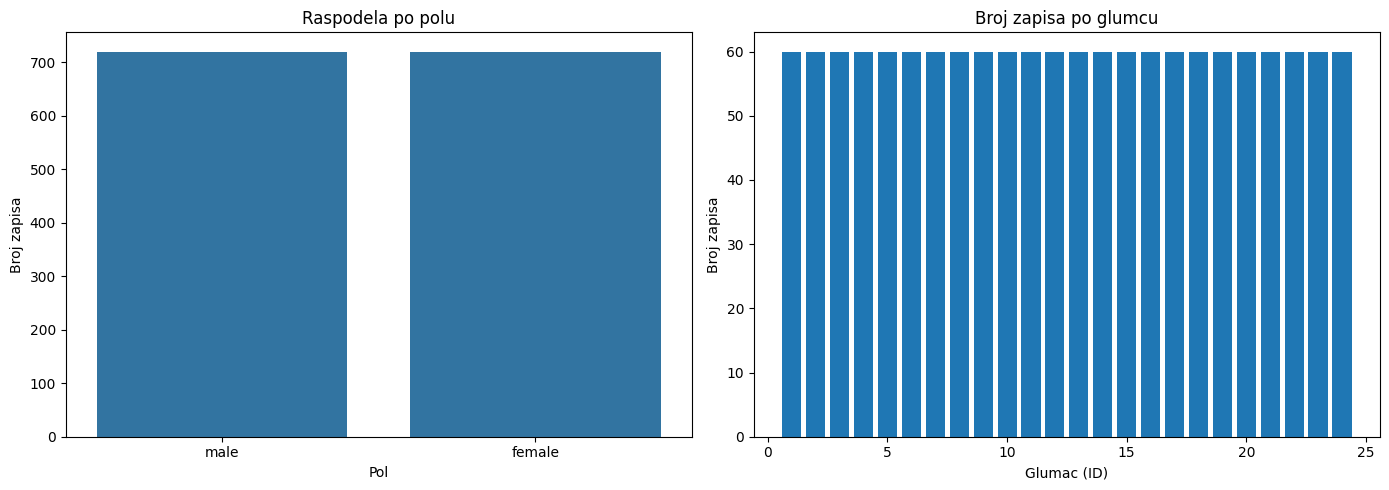

gender
male      720
female    720
Name: count, dtype: int64
Broj glumaca: 24, prosecno zapisa po glumcu: 60.0


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_labels, x="gender", ax=axes[0])
axes[0].set_title("Raspodela po polu")
axes[0].set_xlabel("Pol")
axes[0].set_ylabel("Broj zapisa")

actor_counts = df_labels.groupby("actor").size()
axes[1].bar(actor_counts.index, actor_counts.values)
axes[1].set_title("Broj zapisa po glumcu")
axes[1].set_xlabel("Glumac (ID)")
axes[1].set_ylabel("Broj zapisa")

plt.tight_layout()
plt.savefig("visualization/eda_photos/gender_actor_distribution.png")
plt.show()

print(df_labels["gender"].value_counts())
print(f"Broj glumaca: {df_labels['actor'].nunique()}, prosecno zapisa po glumcu: {actor_counts.mean():.1f}")


### 3. Raspodela trajanja audio zapisa

Provera da su zapisi u očekivanom opsegu trajanja (relevantno jer se u pipeline-u koristi fiksan isečak od 3 sekunde, počevši od offset-a 0.5s). Ova ćelija čita svaki .wav fajl da izmeri trajanje — traje par minuta za ceo skup (1440 zapisa).

c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Merenje trajanja: 100%|██████████| 1440/1440 [00:01<00:00, 832.25it/s] 


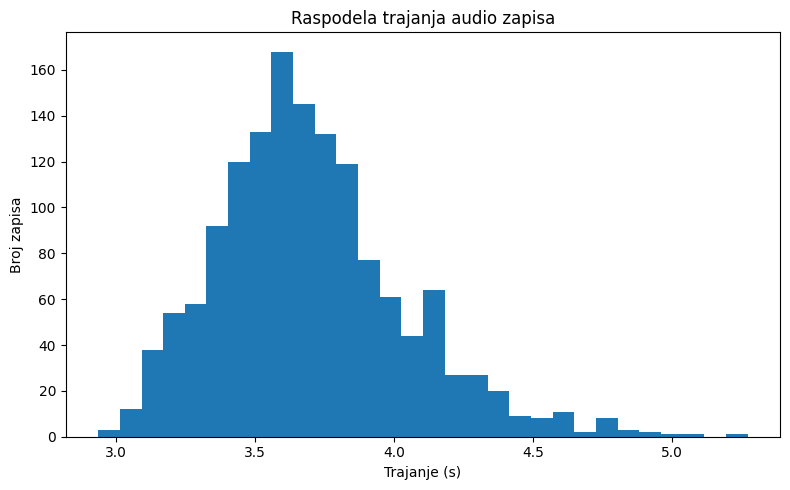

count    1440.000000
mean        3.700665
std         0.336676
min         2.936271
25%         3.470146
50%         3.670333
75%         3.870542
max         5.271937
Name: duration, dtype: float64


In [3]:
import librosa
from tqdm.auto import tqdm

durations = [librosa.get_duration(path=p) for p in tqdm(df_labels["path"], desc="Merenje trajanja")]
df_labels["duration"] = durations

plt.figure(figsize=(8, 5))
plt.hist(df_labels["duration"], bins=30)
plt.title("Raspodela trajanja audio zapisa")
plt.xlabel("Trajanje (s)")
plt.ylabel("Broj zapisa")
plt.tight_layout()
plt.savefig("visualization/eda_photos/duration_distribution.png")
plt.show()

print(df_labels["duration"].describe())


---

## Kvalitativna vizualizacija primera

## Waveform (Wave) slika

**Šta je**: Grafički prikaz audio signala u vremenskoj domeni. Na X osi je vreme, na Y osi amplituda zvuka.

**Za šta služi**: Prikazuje oblik talasa i dinamiku zvuka.
Može se koristiti da se vizualno identifikuju tihe i glasne sekvence, promene intenziteta i trajanje zvuka.

**Primer**: female_happy_wave.png prikazuje amplitudu audio signala za ženu koja izražava sreću.

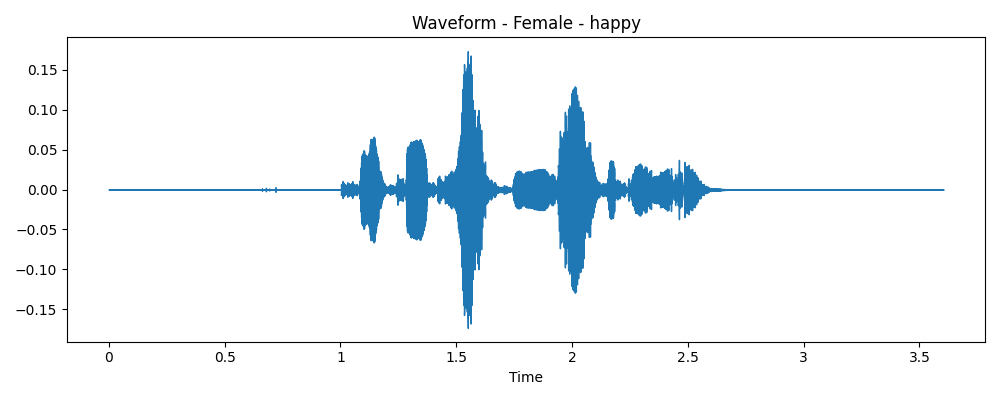

In [4]:
from IPython.display import Image, display
import os

# Folder gde su sačuvane slike
folder = "visualization/eda_photos"

# Ime slike
img_file = "female_happy_wave.png"  # npr. waveform za ženu koja je srećna

# Prikaz slike
display(Image(filename=os.path.join(folder, img_file)))



## Mel spektrogram (Melspec) slika

**Šta je**: Grafički prikaz frekvencijskog sadržaja zvuka u Mel skali.
- X osa: vreme
- Y osa: frekvencija (Mel skala, prilagođena ljudskom sluhu)
- Boja/jačina: amplituda signala na određenoj frekvenciji

**Za šta služi**:
Pruža bogatiji uvid u frekvencijski sadržaj audio signala nego waveform.
Koristi se kao ulaz za CNN ili druge modele za prepoznavanje zvuka/emosija, jer model može bolje uočiti obrasce i tonove u zvuku.

**Primer**: female_happy_melspec.png prikazuje frekvencijski sadržaj zvuka za ženu koja izražava sreću.

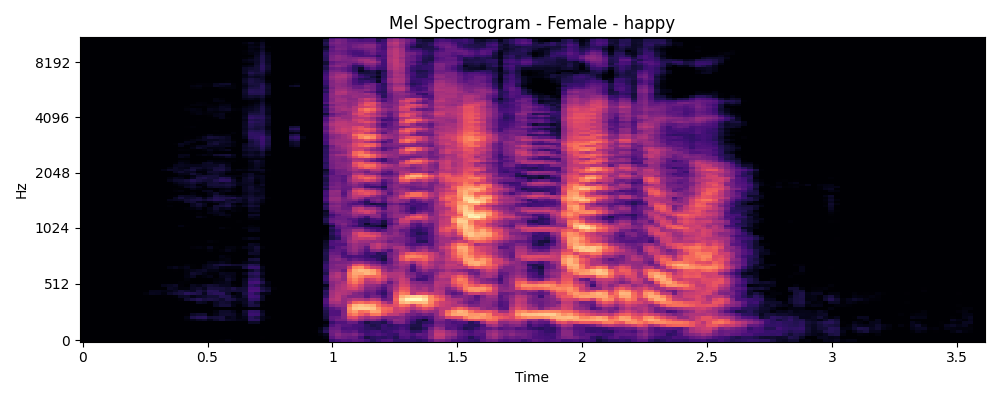

In [5]:
from IPython.display import Image, display
import os

# Folder gde su sačuvane slike
folder = "visualization/eda_photos"

# Ime slike
img_file = "female_happy_melspec.png"  # npr. waveform za ženu koja je srećna

# Prikaz slike
display(Image(filename=os.path.join(folder, img_file)))

---

## 4. Vizualizacija prostora karakteristika (PCA)

Mean/std/max Mel-spektrogram karakteristike (384 dimenzije, iste kao za KNN/Naive Bayes) svedene na 2 dimenzije pomoću PCA, obojene po emociji. Ova vizualizacija pokazuje koliko se emocije preklapaju u prostoru karakteristika — direktno objašnjava zašto KNN i Naive Bayes imaju ograničenu tačnost: ako se klase vizuelno mešaju u 2D projekciji, to je znak da ni u punom, 384-dimenzionom prostoru nisu lako razdvojive linearnim ili udaljenosnim metodama.

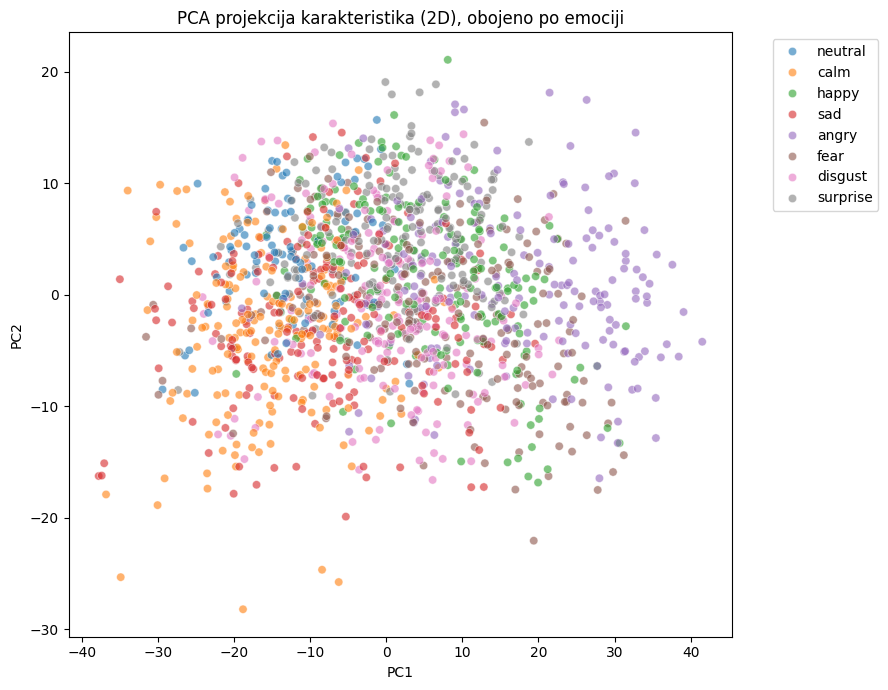

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

features_df = pd.read_csv("data/processed_data/knn_and_nb/features_mel_extended.csv")
feature_cols = [c for c in features_df.columns if c not in ["emotion", "gender", "actor", "path"]]

X = features_df[feature_cols].values
y = features_df["emotion"].values

X_scaled = StandardScaler().fit_transform(X)
X_pca = PCA(n_components=2).fit_transform(X_scaled)

plt.figure(figsize=(9, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette="tab10", alpha=0.6)
plt.title("PCA projekcija karakteristika (2D), obojeno po emociji")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("visualization/eda_photos/pca_feature_space.png")
plt.show()
